### Task 3

In [ ]:
!mkdir -p /content/CSE425_project
!mkdir -p /content/CSE425_project/data

print("Project folder created at: /content/CSE425_project")

Project folder created at: /content/CSE425_project


In [ ]:
import os
PROJECT_ROOT = "/content/CSE425_project"
os.chdir(PROJECT_ROOT)
print("Current directory:", os.getcwd())

Current directory: /content/CSE425_project


In [ ]:
!pip install -q torch torchvision torchaudio
!pip install -q transformers datasets
!pip install -q librosa soundfile
!pip install -q scikit-learn pandas numpy matplotlib seaborn
!pip install -q tqdm jupyter
!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
!pip install -q torch-geometric

In [ ]:
MUSICCAPS_DIR = "/content/CSE425_project/data/raw/musiccaps"
os.makedirs(MUSICCAPS_DIR, exist_ok=True)

In [ ]:
!wget -O /content/CSE425_project/data/raw/musiccaps/musiccaps-public.csv \
https://huggingface.co/datasets/google/MusicCaps/resolve/main/musiccaps-public.csv

--2026-09-10 16:14:20--  https://huggingface.co/datasets/google/MusicCaps/resolve/main/musiccaps-public.csv
Resolving huggingface.co (huggingface.co)... 13.35.202.34, 13.35.202.40, 13.35.202.97, ...
Connecting to huggingface.co (huggingface.co)|13.35.202.34|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/63d3fb232424c652f6f47b39/81b89084316f3d79cc16c3207c09625ac91860a34a98d5766ae0da80547e2caf?user_id=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27musiccaps-public.csv%3B+filename%3D%22musiccaps-public.csv%22%3B&X-Xet-Cas-Uid=public&response-content-type=text%2Fcsv&Expires=1789060460&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjNkM2ZiMjMyNDI0YzY1MmY2ZjQ3YjM5LzgxYjg5MDg0MzE2ZjNkNzljYzE2YzMyMDdjMDk2MjVhYzkxODYwYTM0YTk4ZDU3NjZhZTBkYTgwNTQ3ZTJjYWZcXD91c2VyX2lkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSomWC1YZXQtQ2FzLVVpZD1wdWJsaWMmcmVzcG9uc2Ut

In [ ]:
import pandas as pd

metadata_path = "/content/CSE425_project/data/raw/musiccaps/musiccaps-public.csv"
musiccaps_df = pd.read_csv(metadata_path)

print("Number of samples:", len(musiccaps_df))

Number of samples: 5521


In [ ]:
for i in range(5):
    print(f"\n--- Sample {i} ---")
    print("ID:", musiccaps_df.loc[i, "ytid"])
    print("Time:", musiccaps_df.loc[i, "start_s"], "→", musiccaps_df.loc[i, "end_s"])
    print("Caption:", musiccaps_df.loc[i, "caption"])
    print("Aspects:", musiccaps_df.loc[i, "aspect_list"])


--- Sample 0 ---
ID: -0Gj8-vB1q4
Time: 30 → 40
Caption: The low quality recording features a ballad song that contains sustained strings, mellow piano melody and soft female vocal singing over it. It sounds sad and soulful, like something you would hear at Sunday services.
Aspects: ['low quality', 'sustained strings melody', 'soft female vocal', 'mellow piano melody', 'sad', 'soulful', 'ballad']

--- Sample 1 ---
ID: -0SdAVK79lg
Time: 30 → 40
Caption: This song features an electric guitar as the main instrument. The guitar plays a descending run in the beginning then plays an arpeggiated chord followed by a double stop hammer on to a higher note and a descending slide followed by a descending chord run. The percussion plays a simple beat using rim shots. The percussion plays in common time. The bass plays only one note on the first count of each bar. The piano plays backing chords. There are no voices in this song. The mood of this song is relaxing. This song can be played in a coffee

In [ ]:
print(musiccaps_df.shape)
print(musiccaps_df.columns)

(5521, 9)
Index(['ytid', 'start_s', 'end_s', 'audioset_positive_labels', 'aspect_list',
       'caption', 'author_id', 'is_balanced_subset', 'is_audioset_eval'],
      dtype='object')


In [ ]:
print(
    musiccaps_df[["start_s", "end_s"]]
    .drop_duplicates()
    .head(20)
)

    start_s  end_s
0        30     40
10      230    240
12       70     80
14      280    290
15      110    120
16      450    460
22      410    420
24        0     10
26      290    300
27       40     50
28       50     60
29      260    270
30      190    200
31       90    100
34      330    340
44       60     70
46      520    530
47       21     31
51      350    360
52      360    370


In [ ]:
!pip install -q yt-dlp
!apt-get -qq update
!apt-get -qq install ffmpeg

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
# Create project file structure
PROJECT_ROOT = '/content/CSE425_project'

AUDIO_DIR = f'{PROJECT_ROOT}/data/raw/musiccaps/audio'
CSV_PATH = f'{PROJECT_ROOT}/data/raw/musiccaps/musiccaps-public.csv'

directories = {

    'data_processed': f'{PROJECT_ROOT}/data/processed',
    'data_processed_graphs': f'{PROJECT_ROOT}/data/processed/graphs',
    'data_processed_melspec': f'{PROJECT_ROOT}/data/processed/mel-spec',
    'data_processed_bert': f'{PROJECT_ROOT}/data/processed/bert_caches',
    'data_splits': f'{PROJECT_ROOT}/data/splits',
    'results': f'{PROJECT_ROOT}/results',
    'results_plots': f'{PROJECT_ROOT}/results/plots',
    'results_metrics': f'{PROJECT_ROOT}/results/metrics',
    'results_retrieval': f'{PROJECT_ROOT}/results/retrieval_examples',
    'notebooks': f'{PROJECT_ROOT}/notebooks',
    'src': f'{PROJECT_ROOT}/src',
    'report': f'{PROJECT_ROOT}/report',
}

for name, path in directories.items():
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")

Created: /content/CSE425_project/data/processed
Created: /content/CSE425_project/data/processed/graphs
Created: /content/CSE425_project/data/processed/mel-spec
Created: /content/CSE425_project/data/processed/bert_caches
Created: /content/CSE425_project/data/splits
Created: /content/CSE425_project/results
Created: /content/CSE425_project/results/plots
Created: /content/CSE425_project/results/metrics
Created: /content/CSE425_project/results/retrieval_examples
Created: /content/CSE425_project/notebooks
Created: /content/CSE425_project/src
Created: /content/CSE425_project/report


In [ ]:
# import os
# import subprocess

# output_dir = "/content/CSE425_project/data/raw/musiccaps/audio"
# os.makedirs(output_dir, exist_ok=True)

# failed = []

# for _, row in musiccaps_df.head(2000).iterrows():

#     ytid = row["ytid"]
#     start = float(row["start_s"])
#     end = float(row["end_s"])
#     duration = end - start

#     temp_path = f"{output_dir}/{ytid}_full.wav"
#     final_path = f"{output_dir}/{ytid}.wav"

#     print(f"Processing {ytid}: {start} → {end}")

#     if os.path.exists(final_path):
#         print("Already exists, skipping.")
#         continue

#     result = subprocess.run(
#         [
#             "yt-dlp",
#             "-x",
#             "--audio-format", "wav",
#             "-o", temp_path,
#             f"https://www.youtube.com/watch?v={ytid}"
#         ],
#         capture_output=True,
#         text=True
#     )

#     if result.returncode != 0 or not os.path.exists(temp_path):
#         print(f"DOWNLOAD FAILED: {ytid}")
#         failed.append(ytid)
#         continue

#     result = subprocess.run(
#         [
#             "ffmpeg",
#             "-y",
#             "-i", temp_path,
#             "-ss", str(start),
#             "-t", str(duration),
#             "-ac", "1",
#             final_path
#         ],
#         capture_output=True,
#         text=True
#     )

#     if result.returncode != 0 or not os.path.exists(final_path):
#         print(f"EXTRACTION FAILED: {ytid}")
#         failed.append(ytid)

#     else:
#         print(f"Saved: {final_path}")

#     if os.path.exists(temp_path):
#         os.remove(temp_path)

In [ ]:
# ----------------------------
# Audio Files Uploaded from PC
# ----------------------------

In [ ]:
# ------------------------------------
# Number of Audio Files Uploaded: 1430
# ------------------------------------

In [ ]:
# Write tag_pipeline.py
from pathlib import Path

TAG_PIPELINE = r'''
"""
Tag pipeline for MusicCaps' aspect_list.
  parse_aspect_list  -> ['pop','melancholic'] from "['pop','melancholic']"
  build_tag_vocab    -> top-K tags from TRAIN split only
  compute_tag_stats  -> label distribution diagnostics
  categorize_tags    -> structural regex + embedding centroid categorization
"""
import ast, json, re, functools
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch


# Parsing
def parse_aspect_list(raw):
    if not isinstance(raw, str):
        return []
    try:
        items = ast.literal_eval(raw)
    except (ValueError, SyntaxError):
        return []
    return [str(x).strip().lower() for x in items if str(x).strip()]


# Vocabulary
def build_tag_vocab(df, top_k=60, min_count=5):
    counter = Counter()
    for raw in df["aspect_list"]:
        counter.update(parse_aspect_list(raw))
    return [t for t, c in counter.most_common() if c >= min_count][:top_k]


def save_vocab(vocab, path):
    Path(path).write_text(json.dumps(vocab, indent=2))


def load_vocab(path):
    return json.loads(Path(path).read_text())


def compute_tag_stats(df, vocab):
    all_counts = Counter()
    multihot = []
    for raw in df["aspect_list"]:
        tags = parse_aspect_list(raw)
        all_counts.update(tags)
        multihot.append([1 if t in tags else 0 for t in vocab])
    mh = torch.tensor(multihot, dtype=torch.float32)
    vocab_counts = [(t, all_counts.get(t, 0)) for t in vocab]
    return {
        "vocab_size": len(vocab),
        "total_unique_tags_in_data": len(all_counts),
        "most_common_overall": all_counts.most_common(10),
        "least_common_in_vocab": sorted(vocab_counts, key=lambda x: x[1])[:10],
        "avg_labels_per_sample": mh.sum(dim=1).mean().item(),
        "max_labels_per_sample": int(mh.sum(dim=1).max().item()),
        "samples_with_zero_labels": int((mh.sum(dim=1) == 0).sum().item()),
        "sparsity": 1 - (mh.sum().item() / (len(df) * len(vocab))),
    }


# Categorization
# Layer 1: structural regex rules (order matters -- first match wins)
_STRUCTURAL_RULES = [
    ("vocal",      re.compile(r"\b(vocal|voice|singer|singing|choir|humming|instrumental)\b")),
    ("tempo",      re.compile(r"(\btempo\b|uptempo|\bmid-tempo\b|\bmidtempo\b|\bslow\b|\bfast\b)")),
    ("production", re.compile(r"\b(quality|recording|mono|stereo|noisy|reverb|distortion|mix|muddy|lo-fi|hifi|live|performance)\b")),
    ("instrument", re.compile(r"\b(piano|guitar|bass|drum|snare|kick|hat|synth|organ|violin|"
                              r"sax|trumpet|flute|cello|string|percussion|clap|keyboard|"
                              r"bell|harp|accordion|banjo|mandolin|clarinet|trombone)\b")),
    ("structure",  re.compile(r"\b(intro|outro|verse|chorus|bridge|riff|groove|beat|rhythm|"
                              r"melody|melodic|harmonic|chord|progression)\b")),
]

# Layer 2: seed phrases for embedding-based nearest-centroid fallback
_CATEGORY_SEEDS = {
    "genre":      ["pop music", "rock song", "jazz tune", "electronic dance track",
                   "folk ballad", "hip hop beat", "classical piece"],
    "mood":       ["happy and joyful", "sad and melancholic", "energetic and intense",
                   "calm and relaxing", "aggressive and angry", "romantic and sentimental",
                   "dark and moody", "uplifting and hopeful"],
    "instrument": ["solo piano", "electric guitar riff", "acoustic guitar",
                   "synthesizer pad", "live drums", "bass line"],
    "vocal":      ["male singer", "female vocalist", "instrumental no vocals",
                   "choir singing", "spoken word"],
    "tempo":      ["slow tempo", "fast tempo", "moderate tempo", "uptempo dance"],
    "production": ["lo-fi recording", "clean studio mix", "live performance",
                   "amateur recording", "noisy audio"],
    "structure":  ["has a catchy chorus", "extended instrumental intro",
                   "repeating chord progression", "drop and build"],
}

_FALLBACK = "other"


@functools.lru_cache(maxsize=1)
def _get_encoder():
    from sentence_transformers import SentenceTransformer
    return SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")


@functools.lru_cache(maxsize=1)
def _get_centroids():
    enc = _get_encoder()
    centroids = {}
    for cat, seeds in _CATEGORY_SEEDS.items():
        embs = enc.encode(seeds, normalize_embeddings=True)
        c = embs.mean(axis=0)
        centroids[cat] = c / (np.linalg.norm(c) + 1e-9)
    return centroids


def _structural_category(tag):
    for cat, pat in _STRUCTURAL_RULES:
        if pat.search(tag):
            return cat
    return None


def _semantic_category(tag, min_similarity=0.25):
    enc = _get_encoder()
    v = enc.encode([tag], normalize_embeddings=True)[0]
    best_cat, best_sim = None, -1.0
    for cat, c in _get_centroids().items():
        sim = float(np.dot(v, c))
        if sim > best_sim:
            best_sim, best_cat = sim, cat
    return best_cat if best_sim >= min_similarity else None


def categorize_tag(tag):
    """Assign one tag -> (category, method). NOT recursive."""
    cat = _structural_category(tag)
    if cat is not None:
        return cat, "structural"
    cat = _semantic_category(tag)
    if cat is not None:
        return cat, "semantic"
    return _FALLBACK, "fallback"


def categorize_tags(vocab, verbose=True):
    """Assign every tag in vocab to a category. Returns {cat: [tags]}."""
    buckets = defaultdict(list)
    provenance = {}
    for tag in vocab:
        cat, how = categorize_tag(tag)
        buckets[cat].append(tag)
        provenance[tag] = how

    if verbose:
        print("\n[tag_pipeline] category assignment:")
        for cat, tags in sorted(buckets.items(), key=lambda x: -len(x[1])):
            how_counts = Counter(provenance[t] for t in tags)
            detail = ", ".join(f"{k}={v}" for k, v in how_counts.items())
            print(f"  {cat:12s} ({len(tags):2d})  [{detail}]")

    return dict(buckets)


def category_indices(vocab, categorized, category):
    s = set(categorized.get(category, []))
    return [i for i, t in enumerate(vocab) if t in s]


# Validation & splits
def validate_graphs(df, graph_dir):
    graph_dir = Path(graph_dir)
    missing = [y for y in df["ytid"] if not (graph_dir / f"{y}.pt").exists()]
    return {
        "total_samples": len(df),
        "missing_graphs": len(missing),
        "missing_percentage": 100 * len(missing) / len(df) if len(df) else 0,
        "sample_missing": missing[:5],
    }


def create_musiccaps_splits(df, output_dir, val_ratio=0.15):
    """Official split: test = is_audioset_eval==1; train/val carved from rest."""
    df = df.copy()
    df["is_audioset_eval"] = df["is_audioset_eval"].astype(int)

    test = df[df["is_audioset_eval"] == 1].reset_index(drop=True)
    train_val = df[df["is_audioset_eval"] == 0].reset_index(drop=True)

    if "author_id" in train_val.columns and train_val["author_id"].notna().any():
        from sklearn.model_selection import GroupShuffleSplit
        groups = train_val["author_id"].fillna("unknown").astype(str)
        splitter = GroupShuffleSplit(n_splits=1, test_size=val_ratio, random_state=42)
        tr_idx, va_idx = next(splitter.split(train_val, groups=groups))
        train, val = train_val.iloc[tr_idx], train_val.iloc[va_idx]
    else:
        from sklearn.model_selection import train_test_split
        train, val = train_test_split(train_val, test_size=val_ratio, random_state=42)

    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
    train.to_csv(output_dir / "train.csv", index=False)
    val.to_csv(output_dir / "val.csv", index=False)
    test.to_csv(output_dir / "test.csv", index=False)

    print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)} (official eval)")
    return train, val, test
'''

Path("/content/CSE425_project/src/tag_pipeline.py").write_text(TAG_PIPELINE)
print("tag_pipeline.py written")

tag_pipeline.py written


In [ ]:
# Write graph_builder.py
GRAPH_BUILDER = r'''
"""Build segment graphs from audio (chroma features + similarity edges)."""
import warnings
from pathlib import Path
import numpy as np
import torch
import librosa
from torch_geometric.data import Data
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
warnings.filterwarnings("ignore")


class MusicGraphBuilder:
    def __init__(self, sample_rate=22050, segment_duration=5.0, hop_length=512,
                 n_chroma=12, feature_type="chroma", similarity_threshold=0.7):
        self.sample_rate = sample_rate
        self.segment_duration = segment_duration
        self.hop_length = hop_length
        self.n_chroma = n_chroma
        self.feature_type = feature_type
        self.similarity_threshold = similarity_threshold

    def _features(self, y):
        if self.feature_type == "chroma":
            f = librosa.feature.chroma_stft(
                y=y, sr=self.sample_rate, hop_length=self.hop_length,
                n_chroma=self.n_chroma)
        else:
            f = librosa.power_to_db(
                librosa.feature.melspectrogram(
                    y=y, sr=self.sample_rate, hop_length=self.hop_length),
                ref=np.max)
        return f.T  # (T, D)

    def _segment(self, feats):
        fps = int(self.segment_duration * self.sample_rate / self.hop_length)
        n = max(1, feats.shape[0] // fps)
        segs = []
        for i in range(n):
            s, e = i * fps, min((i + 1) * fps, feats.shape[0])
            if e - s < fps // 2 and i > 0:
                break
            segs.append(feats[s:e].mean(0))
        return np.stack(segs, 0)

    def build(self, audio_path):
        try:
            y, _ = librosa.load(audio_path, sr=self.sample_rate, mono=True)
            if len(y) < self.sample_rate:
                return None
            feats = self._features(y)
            seg = self._segment(feats)
            # Normalize
            seg = (seg - seg.mean(0, keepdims=True)) / (seg.std(0, keepdims=True) + 1e-6)
            x = torch.tensor(seg, dtype=torch.float32)
            n = x.shape[0]

            edges = []
            if n > 1:
                sim = cosine_similarity(seg)
                for i in range(n):
                    for j in range(i + 1, n):
                        if sim[i, j] > self.similarity_threshold:
                            edges += [(i, j), (j, i)]
                for i in range(n - 1):
                    edges += [(i, i + 1), (i + 1, i)]
            if not edges:
                edges = [(i, i) for i in range(n)]

            ei = torch.tensor(edges, dtype=torch.long).t().contiguous()
            return Data(x=x, edge_index=ei, num_nodes=n)
        except Exception as e:
            print(f"[graph_builder] {audio_path}: {e}")
            return None


def build_all_graphs(audio_dir, output_dir, ytids, builder):
    audio_dir, output_dir = Path(audio_dir), Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    built = skipped = failed = 0
    for ytid in tqdm(ytids, desc="Building graphs"):
        out = output_dir / f"{ytid}.pt"
        if out.exists():
            skipped += 1; continue
        ap = audio_dir / f"{ytid}.wav"
        if not ap.exists():
            failed += 1; continue
        g = builder.build(str(ap))
        if g is None:
            failed += 1; continue
        torch.save(g, out)
        built += 1
    print(f"Built={built} Skipped={skipped} Failed={failed}")
    return built, skipped, failed
'''

Path("/content/CSE425_project/src/graph_builder.py").write_text(GRAPH_BUILDER)
print("graph_builder.py written")

graph_builder.py written


In [ ]:
# Write fusion_model.py
FUSION_MODEL = r'''
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import BertModel
from torch_geometric.nn import GraphSAGE, GATConv, global_mean_pool


class GATEncoder(nn.Module):
    def __init__(self, in_dim, hid, out, layers, dropout, heads=4):
        super().__init__()
        self.convs = nn.ModuleList(); self.bns = nn.ModuleList()
        self.dropout = nn.Dropout(dropout)
        for i in range(layers):
            in_ch = in_dim if i == 0 else hid
            out_ch = hid if i < layers - 1 else out
            h = heads if i < layers - 1 else 1
            self.convs.append(GATConv(in_ch, out_ch // h, heads=h,
                                      concat=(h > 1), dropout=dropout))
            if i < layers - 1:
                self.bns.append(nn.BatchNorm1d(out_ch))

    def forward(self, x, ei):
        for i, c in enumerate(self.convs):
            x = c(x, ei)
            if i < len(self.convs) - 1:
                x = self.dropout(F.relu(self.bns[i](x)))
        return x


class FusionModel(nn.Module):
    def __init__(self, gnn_type="graphsage", gnn_input_dim=12,
                 gnn_hidden_dim=128, gnn_output_dim=128, gnn_num_layers=2,
                 bert_model_name="bert-base-uncased",
                 fusion_method="cross_attention", num_tags=60,
                 num_heads=4, dropout=0.3, freeze_bert=False):
        super().__init__()
        self.fusion_method = fusion_method

        if gnn_type == "graphsage":
            self.gnn = GraphSAGE(
                in_channels=gnn_input_dim,
                hidden_channels=gnn_hidden_dim,
                out_channels=gnn_output_dim,
                num_layers=gnn_num_layers,
                dropout=dropout,
                norm=nn.BatchNorm1d(gnn_hidden_dim),
            )
        elif gnn_type == "gat":
            self.gnn = GATEncoder(gnn_input_dim, gnn_hidden_dim,
                                  gnn_output_dim, gnn_num_layers, dropout)
        else:
            raise ValueError(gnn_type)

        self.bert = BertModel.from_pretrained(bert_model_name)
        if freeze_bert:
            for p in self.bert.parameters():
                p.requires_grad = False
        bert_dim = self.bert.config.hidden_size

        if fusion_method == "concat":
            self.text_proj = nn.Linear(bert_dim, gnn_output_dim)
            self.fuse = nn.Sequential(
                nn.Linear(gnn_output_dim * 2, gnn_output_dim),
                nn.ReLU(), nn.Dropout(dropout))
            head_in = gnn_output_dim
        elif fusion_method == "cross_attention":
            self.q_proj = nn.Linear(gnn_output_dim, gnn_output_dim)
            self.kv_proj = nn.Linear(bert_dim, gnn_output_dim)
            self.attn = nn.MultiheadAttention(gnn_output_dim, num_heads,
                                              dropout=dropout, batch_first=True)
            head_in = gnn_output_dim
        elif fusion_method == "bert_only":
            self.text_proj = nn.Linear(bert_dim, gnn_output_dim)
            head_in = gnn_output_dim
        elif fusion_method == "gnn_only":
            head_in = gnn_output_dim
        else:
            raise ValueError(fusion_method)

        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(head_in, head_in),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_in, num_tags),
        )

    def forward(self, graph_x, edge_index, graph_batch,
                input_ids, attention_mask, return_embeddings=False):
        g = None
        if self.fusion_method != "bert_only":
            node = self.gnn(graph_x, edge_index)
            g = global_mean_pool(node, graph_batch)

        t_cls = t_seq = None
        if self.fusion_method != "gnn_only":
            bo = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            # Masked mean pooling over token embeddings
            mask = attention_mask.unsqueeze(-1).float()
            t_cls = (bo.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-6)
            t_seq = bo.last_hidden_state

        if self.fusion_method == "concat":
            fused = self.fuse(torch.cat([g, self.text_proj(t_cls)], 1))
        elif self.fusion_method == "cross_attention":
            kv = self.kv_proj(t_seq)
            q = self.q_proj(g).unsqueeze(1)
            a, _ = self.attn(q, kv, kv, need_weights=False)
            fused = a.squeeze(1)
        elif self.fusion_method == "bert_only":
            fused = self.text_proj(t_cls)
        elif self.fusion_method == "gnn_only":
            fused = g

        fused = self.dropout(fused)
        out = {"tag_logits": self.head(fused)}
        if return_embeddings:
            out["embeddings"] = fused
        return out
'''

Path("/content/CSE425_project/src/fusion_model.py").write_text(FUSION_MODEL)
print("fusion_model.py written")

fusion_model.py written


In [ ]:
# Write data_loader.py
DATA_LOADER = r'''
"""Dataset + collate for MusicCaps fusion training."""
import json, ast
from pathlib import Path
import pandas as pd
import torch
from torch.utils.data import Dataset
from torch_geometric.data import Batch, Data


def parse_aspect_list(raw):
    if not isinstance(raw, str): return []
    try: items = ast.literal_eval(raw)
    except (ValueError, SyntaxError): return []
    return [str(x).strip().lower() for x in items if str(x).strip()]


class MusicCapsFusionDataset(Dataset):
    def __init__(self, split_csv, vocab_path, graph_dir, tokenizer, max_length=128):
        self.df = pd.read_csv(split_csv).reset_index(drop=True)
        self.vocab = json.loads(Path(vocab_path).read_text())
        self.t2i = {t: i for i, t in enumerate(self.vocab)}
        self.graph_dir = Path(graph_dir)
        self.tok = tokenizer
        self.max_length = max_length

    def __len__(self): return len(self.df)

    def _multihot(self, raw):
        y = torch.zeros(len(self.vocab))
        for t in parse_aspect_list(raw):
            if t in self.t2i: y[self.t2i[t]] = 1.0
        return y

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        ytid = row["ytid"]
        gp = self.graph_dir / f"{ytid}.pt"
        if gp.exists():
            g = torch.load(gp, weights_only=False)
        else:
            g = Data(x=torch.zeros(1, 12),
                     edge_index=torch.tensor([[0],[0]], dtype=torch.long),
                     num_nodes=1)
        cap = row.get("caption", "")
        if not isinstance(cap, str) or not cap.strip():
            cap = "[PAD]"
        enc = self.tok(cap, truncation=True, padding="max_length",
                       max_length=self.max_length, return_tensors="pt")
        return {
            "graph": g,
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": self._multihot(row["aspect_list"]),
            "ytid": ytid,
            "caption": cap,
        }


def collate_fn(batch):
    gs = Batch.from_data_list([b["graph"] for b in batch])
    return {
        "graph_x": gs.x,
        "edge_index": gs.edge_index,
        "graph_batch": gs.batch,
        "input_ids": torch.stack([b["input_ids"] for b in batch]),
        "attention_mask": torch.stack([b["attention_mask"] for b in batch]),
        "labels": torch.stack([b["labels"] for b in batch]),
        "ytids": [b["ytid"] for b in batch],
        "captions": [b["caption"] for b in batch],
    }
'''

Path("/content/CSE425_project/src/data_loader.py").write_text(DATA_LOADER)
print("data_loader.py written")

data_loader.py written


In [ ]:
# Write train.py
TRAIN = r'''
import sys, json, argparse, warnings
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from transformers import BertTokenizer
from sklearn.metrics import f1_score, average_precision_score
from sklearn.exceptions import UndefinedMetricWarning
from tqdm import tqdm

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
warnings.filterwarnings("ignore", message=".*No positive class.*")

sys.path.append("/content/CSE425_project/src")
from data_loader import MusicCapsFusionDataset, collate_fn
from fusion_model import FusionModel
from tag_pipeline import categorize_tags, category_indices


def compute_metrics(T, P, cat_idx, thr=0.5):
    b = (P > thr).astype(int)
    m = {
        "macro_f1": f1_score(T, b, average="macro", zero_division=0),
        "micro_f1": f1_score(T, b, average="micro", zero_division=0),
        "auc_pr":   average_precision_score(T, P, average="macro")
                    if T.sum() > 0 else 0.0,
    }
    for cat, idxs in cat_idx.items():
        if not idxs: continue
        ct, cb = T[:, idxs], b[:, idxs]
        if ct.sum() > 0:
            m[f"{cat}_f1"] = f1_score(ct, cb, average="macro", zero_division=0)
    return m


def best_threshold(T, P, grid=np.arange(0.05, 0.55, 0.05)):
    best_t, best_f1 = 0.5, -1.0
    for t in grid:
        b = (P > t).astype(int)
        if b.sum() == 0: continue
        f1 = f1_score(T, b, average="macro", zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


def run_epoch(model, loader, opt, crit, dev, train, cat_idx):
    model.train() if train else model.eval()
    losses, T, P = [], [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        pbar = tqdm(loader, leave=False, desc="train" if train else "eval")
        for b in pbar:
            gx = b["graph_x"].to(dev); ei = b["edge_index"].to(dev)
            gb = b["graph_batch"].to(dev)
            ii = b["input_ids"].to(dev); am = b["attention_mask"].to(dev)
            y  = b["labels"].to(dev)
            out = model(gx, ei, gb, ii, am)
            logits = out["tag_logits"]
            loss = crit(logits, y)
            if train:
                opt.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            losses.append(loss.item())
            T.append(y.detach().cpu().numpy())
            P.append(torch.sigmoid(logits).detach().cpu().numpy())
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    T, P = np.vstack(T), np.vstack(P)
    m = {"loss": float(np.mean(losses))}
    m.update(compute_metrics(T, P, cat_idx))
    m["T"] = T
    m["P"] = P
    return m


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--fusion_method", default="cross_attention",
                    choices=["concat","cross_attention","bert_only","gnn_only"])
    ap.add_argument("--gnn_type", default="graphsage", choices=["graphsage","gat"])
    ap.add_argument("--epochs", type=int, default=15)
    ap.add_argument("--batch_size", type=int, default=16)
    ap.add_argument("--lr", type=float, default=5e-5)
    ap.add_argument("--freeze_bert", action="store_true")
    ap.add_argument("--num_workers", type=int, default=2)
    args = ap.parse_args()

    ROOT = Path("/content/CSE425_project")
    DATA = ROOT / "data/task3_ready"
    GRAPHS = ROOT / "data/processed/graphs"
    tag = f"{args.fusion_method}_{args.gnn_type}"
    SAVE = ROOT / "models" / tag; SAVE.mkdir(parents=True, exist_ok=True)
    LOG  = ROOT / "runs" / tag

    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {dev}")

    vocab = json.loads((DATA / "tag_vocab.json").read_text())
    cats = categorize_tags(vocab, verbose=False)
    cat_idx = {c: category_indices(vocab, cats, c) for c in cats}
    print(f"Vocab={len(vocab)}")

    tok = BertTokenizer.from_pretrained("bert-base-uncased")
    train_ds = MusicCapsFusionDataset(DATA/"train.csv", DATA/"tag_vocab.json", GRAPHS, tok)
    val_ds   = MusicCapsFusionDataset(DATA/"val.csv",   DATA/"tag_vocab.json", GRAPHS, tok)
    test_ds  = MusicCapsFusionDataset(DATA/"test.csv",  DATA/"tag_vocab.json", GRAPHS, tok)

    train_ld = DataLoader(train_ds, batch_size=args.batch_size, shuffle=True,
                          collate_fn=collate_fn, num_workers=args.num_workers)
    val_ld   = DataLoader(val_ds, batch_size=args.batch_size, shuffle=False,
                          collate_fn=collate_fn, num_workers=args.num_workers)
    test_ld  = DataLoader(test_ds, batch_size=args.batch_size, shuffle=False,
                          collate_fn=collate_fn, num_workers=args.num_workers)

    model = FusionModel(
        gnn_type=args.gnn_type, gnn_input_dim=12,
        gnn_hidden_dim=128, gnn_output_dim=128, gnn_num_layers=2,
        fusion_method=args.fusion_method, num_tags=len(vocab),
        num_heads=4, dropout=0.3, freeze_bert=args.freeze_bert,
    ).to(dev)

    # ---- Split LR ----
    bert_params = [p for n, p in model.named_parameters()
                   if n.startswith("bert.") and p.requires_grad]
    head_params = [p for n, p in model.named_parameters()
                   if not n.startswith("bert.") and p.requires_grad]
    print(f"Trainable BERT params: {sum(p.numel() for p in bert_params):,}")
    print(f"Trainable head params: {sum(p.numel() for p in head_params):,}")

    opt = optim.AdamW([
        {"params": bert_params, "lr": args.lr},
        {"params": head_params, "lr": args.lr * 10},
    ], weight_decay=1e-4)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min",
                                               factor=0.5, patience=3)

    # ---- Capped pos_weight ----
    all_y = np.stack([train_ds[i]["labels"].numpy() for i in range(len(train_ds))])
    pos = all_y.sum(axis=0); neg = len(all_y) - pos
    pos_weight = torch.tensor(
        np.clip(neg / (pos + 1e-6), 1.0, 10.0), dtype=torch.float32
    ).to(dev)
    print(f"pos_weight: min={pos_weight.min():.2f} "
          f"max={pos_weight.max():.2f} mean={pos_weight.mean():.2f}")
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    writer = SummaryWriter(str(LOG))
    best_val_loss = float("inf")
    best_ep, best_thresh = 0, 0.5

    for ep in range(1, args.epochs + 1):
        tr = run_epoch(model, train_ld, opt, crit, dev, True, cat_idx)
        va = run_epoch(model, val_ld,   opt, crit, dev, False, cat_idx)
        t_opt, f1_opt = best_threshold(va["T"], va["P"])

        print(f"\nEpoch {ep}/{args.epochs}")
        print(f"  train loss={tr['loss']:.4f} mF1={tr['macro_f1']:.4f} "
              f"AUC-PR={tr['auc_pr']:.4f}")
        print(f"  val   loss={va['loss']:.4f} mF1={va['macro_f1']:.4f} "
              f"| @thr={t_opt:.2f} mF1={f1_opt:.4f} AUC-PR={va['auc_pr']:.4f}")

        for k, v in tr.items():
            if isinstance(v, (int, float)): writer.add_scalar(f"train/{k}", v, ep)
        for k, v in va.items():
            if isinstance(v, (int, float)): writer.add_scalar(f"val/{k}", v, ep)

        sch.step(va["loss"])

        if va["loss"] < best_val_loss:
            best_val_loss, best_ep, best_thresh = va["loss"], ep, t_opt
            torch.save({"model": model.state_dict(), "vocab": vocab,
                        "args": vars(args), "epoch": ep,
                        "val_loss": best_val_loss, "threshold": best_thresh},
                       SAVE / "best.pt")
            print(f"  ✓ saved (val_loss={best_val_loss:.4f}, thr={t_opt:.2f})")

    print(f"\nBest val_loss={best_val_loss:.4f} @ ep{best_ep} | thr={best_thresh:.2f}")

    # ---- Test with best checkpoint + tuned threshold ----
    ck = torch.load(SAVE / "best.pt", weights_only=False)
    model.load_state_dict(ck["model"])
    best_thresh = ck["threshold"]
    te = run_epoch(model, test_ld, opt, crit, dev, False, cat_idx)
    b = (te["P"] > best_thresh).astype(int)

    te_final = {
        "threshold": float(best_thresh),
        "epoch": int(best_ep),
        "macro_f1": f1_score(te["T"], b, average="macro", zero_division=0),
        "micro_f1": f1_score(te["T"], b, average="micro", zero_division=0),
        "auc_pr":   average_precision_score(te["T"], te["P"], average="macro"),
    }
    for cat, idxs in cat_idx.items():
        if not idxs: continue
        ct, cb = te["T"][:, idxs], b[:, idxs]
        if ct.sum() > 0:
            te_final[f"{cat}_f1"] = f1_score(ct, cb, average="macro", zero_division=0)

    print("\n=== Test (best checkpoint + tuned threshold) ===")
    for k, v in te_final.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

    (SAVE / "test_metrics.json").write_text(json.dumps(te_final, indent=2))
    writer.close()


if __name__ == "__main__":
    main()
'''

Path("/content/CSE425_project/src/train.py").write_text(TRAIN)
print("train.py written")

train.py written


In [ ]:
# Run full preprocessing
import sys, pandas as pd
sys.path.append("/content/CSE425_project/src")

from tag_pipeline import (
    build_tag_vocab, save_vocab, compute_tag_stats,
    categorize_tags, validate_graphs, create_musiccaps_splits,
)
from graph_builder import MusicGraphBuilder, build_all_graphs

ROOT = Path("/content/CSE425_project")
CSV_PATH = ROOT / "data/raw/musiccaps/musiccaps-public.csv"
AUDIO_DIR = ROOT / "data/raw/musiccaps/audio"
GRAPH_DIR = ROOT / "data/processed/graphs"
OUT_DIR = ROOT / "data/task3_ready"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Load CSV and keep only clips we have audio for
df = pd.read_csv(CSV_PATH)
have_audio = {p.stem for p in AUDIO_DIR.glob("*.wav")}
df = df[df["ytid"].isin(have_audio)].reset_index(drop=True)
print(f"MusicCaps rows with audio: {len(df)}")

# 2. Build graphs
builder = MusicGraphBuilder(
    feature_type="chroma", segment_duration=5.0, similarity_threshold=0.7,
)
build_all_graphs(AUDIO_DIR, GRAPH_DIR, df["ytid"].tolist(), builder)

# 3. Official splits
train_df, val_df, test_df = create_musiccaps_splits(df, OUT_DIR, val_ratio=0.15)

# 4. Vocabulary from TRAIN only
vocab = build_tag_vocab(train_df, top_k=60, min_count=5)
save_vocab(vocab, OUT_DIR / "tag_vocab.json")
print(f"\nVocab size: {len(vocab)}")
print(f"Top 20: {vocab[:20]}")

# 5. Diagnostics
stats = compute_tag_stats(train_df, vocab)
print("\n--- Tag stats ---")
for k, v in stats.items():
    if k not in ("most_common_overall", "least_common_in_vocab"):
        print(f"  {k}: {v}")
print(f"  most common: {stats['most_common_overall'][:5]}")

cats = categorize_tags(vocab)
print("\n--- Category breakdown ---")
for c, tags in cats.items():
    print(f"  {c}: {len(tags)} -> {tags[:6]}")

g = validate_graphs(df, GRAPH_DIR)
print(f"\n--- Graph check --- {g['missing_graphs']} missing ({g['missing_percentage']:.1f}%)")

MusicCaps rows with audio: 1428


Building graphs: 100%|██████████| 1428/1428 [01:21<00:00, 17.48it/s]


Built=1427 Skipped=0 Failed=1
Train: 571, Val: 123, Test: 734 (official eval)

Vocab size: 60
Top 20: ['low quality', 'noisy', 'instrumental', 'passionate', 'amateur recording', 'mono', 'emotional', 'energetic', 'acoustic drums', 'slow tempo', 'shimmering hi hats', 'moderate tempo', 'piano', 'live performance', 'groovy bass', 'male voice', 'punchy snare', 'bass', 'punchy kick', 'male vocal']

--- Tag stats ---
  vocab_size: 60
  total_unique_tags_in_data: 1662
  avg_labels_per_sample: 3.2049036026000977
  max_labels_per_sample: 10
  samples_with_zero_labels: 50
  sparsity: 0.946584938704028
  most common: [('low quality', 164), ('noisy', 86), ('instrumental', 82), ('passionate', 75), ('amateur recording', 61)]


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


[tag_pipeline] category assignment:
  instrument   (18)  [semantic=5, structural=13]
  mood         (15)  [semantic=15]
  vocal        (10)  [structural=9, semantic=1]
  production   ( 7)  [structural=7]
  tempo        ( 7)  [structural=6, semantic=1]
  genre        ( 2)  [semantic=2]
  other        ( 1)  [fallback=1]

--- Category breakdown ---
  production: 7 -> ['low quality', 'noisy', 'amateur recording', 'mono', 'live performance', 'low quality audio']
  vocal: 10 -> ['instrumental', 'male voice', 'male vocal', 'no voices', 'flat male vocal', 'melodic singing']
  mood: 15 -> ['passionate', 'emotional', 'energetic', 'shimmering hi hats', 'groovy', 'upbeat']
  instrument: 18 -> ['acoustic drums', 'piano', 'groovy bass', 'punchy snare', 'bass', 'punchy kick']
  tempo: 7 -> ['slow tempo', 'moderate tempo', 'medium tempo', 'uptempo', 'medium to uptempo', 'fast tempo']
  genre: 2 -> ['pop', 'rock']
  other: 1 -> ['claps']

--- Graph check --- 1 missing (0.1%)


In [ ]:
# Train the cross-attention fusion model
!cd /content/CSE425_project && python src/train.py \
    --fusion_method cross_attention \
    --gnn_type graphsage \
    --epochs 20 \
    --batch_size 16

Device: cuda
Loading weights: 100% 103/103 [00:00<00:00, 5705.48it/s]
Vocab=60
Loading weights: 100% 199/199 [00:00<00:00, 4408.41it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Trainable BERT params: 109,482,240
Trainable head params: 241,596
pos_weight: min=2.48 max=10.00 mean=9.62

Epoch 1/20
  tra

In [ ]:
# Ablaiton Study
import subprocess, sys, json
from pathlib import Path
import pandas as pd

ROOT = Path("/content/CSE425_project")
methods = ["bert_only", "gnn_only", "concat", "cross_attention"]
EPOCHS = 15
BATCH = 16

results = {}

for m in methods:
    print(f"\n{'='*70}", flush=True)
    print(f"Running: {m}", flush=True)
    print(f"{'='*70}", flush=True)

    cmd = [
        sys.executable, "src/train.py",
        "--fusion_method", m,
        "--gnn_type", "graphsage",
        "--epochs", str(EPOCHS),
        "--batch_size", str(BATCH),
        "--lr", "5e-5",
    ]
    print("CMD:", " ".join(cmd), flush=True)

    try:
        subprocess.run(cmd, cwd=ROOT, check=True)
        print(f"\n{m} done", flush=True)
    except subprocess.CalledProcessError as e:
        print(f"\n{m} FAILED (rc={e.returncode})", flush=True)
        print(f"   Run manually:  cd {ROOT} && {' '.join(cmd)}", flush=True)
        continue

    p = ROOT / f"models/{m}_graphsage/test_metrics.json"
    if p.exists():
        results[m] = json.loads(p.read_text())
        print(f"   {results[m]}", flush=True)
    else:
        print(f"   no test_metrics.json for {m}", flush=True)

if results:
    df = pd.DataFrame([{"method": k, **v} for k, v in results.items()])
    df.to_csv(ROOT / "results/metrics/ablation.csv", index=False)
    print("\n=== Ablation Results ===")
    print(df.to_string(index=False))
else:
    print("\nno results — check the failures above.")


Running: bert_only
CMD: /usr/bin/python3 src/train.py --fusion_method bert_only --gnn_type graphsage --epochs 15 --batch_size 16 --lr 5e-5

bert_only done
   {'threshold': 0.3, 'epoch': 5, 'macro_f1': 0.22481842141362116, 'micro_f1': 0.2476057809507226, 'auc_pr': 0.2988107505090799, 'production_f1': 0.3360336253621448, 'vocal_f1': 0.22099423462721215, 'mood_f1': 0.18866947718936508, 'instrument_f1': 0.24408031533436692, 'tempo_f1': 0.19482115097150116, 'genre_f1': 0.1252029780324152, 'other_f1': 0.5070322376738305}

Running: gnn_only
CMD: /usr/bin/python3 src/train.py --fusion_method gnn_only --gnn_type graphsage --epochs 15 --batch_size 16 --lr 5e-5

gnn_only done
   {'threshold': 0.25, 'epoch': 9, 'macro_f1': 0.08183733908700445, 'micro_f1': 0.09979721010262398, 'auc_pr': 0.050184965855897, 'production_f1': 0.12747335088496015, 'vocal_f1': 0.06277390941211286, 'mood_f1': 0.07392842275421499, 'instrument_f1': 0.07576942782724166, 'tempo_f1': 0.1096888625465066, 'genre_f1': 0.07005552

In [ ]:
# Write src/visualize.py — 3 figures, no cross-attention
from pathlib import Path

VISUALIZE = r'''
"""
Task 3 report figures (simplified).

Figures:
  ablation_bars.png     -- macro-F1 / micro-F1 / AUC-PR per method
  loss_curves.png       -- 2x2 subplots: train+val loss per method
  lr_schedule.png       -- LR schedule per method

Also displayed inline when imported from a notebook.
"""
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

ROOT = Path("/content/CSE425_project")
PLOTS = ROOT / "results/plots"
PLOTS.mkdir(parents=True, exist_ok=True)

METHODS = ["bert_only", "gnn_only", "concat", "cross_attention"]


# loaders
def load_metrics() -> pd.DataFrame:
    rows = []
    for m in METHODS:
        p = ROOT / f"models/{m}_graphsage/test_metrics.json"
        if p.exists():
            rows.append({"method": m, **json.loads(p.read_text())})
    return pd.DataFrame(rows)


def _read_scalar(log_dir: Path, tag: str):
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
    if not log_dir.exists():
        return None, None
    acc = EventAccumulator(str(log_dir))
    acc.Reload()
    if tag not in acc.Tags()["scalars"]:
        return None, None
    ev = acc.Scalars(tag)
    return np.array([e.step for e in ev]), np.array([e.value for e in ev])


def fig_1(df: pd.DataFrame):
    metrics = ["macro_f1", "micro_f1", "auc_pr"]
    labels  = ["Macro-F1", "Micro-F1", "AUC-PR"]
    x = np.arange(len(df)); w = 0.25

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, (m, lab) in enumerate(zip(metrics, labels)):
        bars = ax.bar(x + i*w, df[m], width=w, label=lab)
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width()/2, h + 0.005, f"{h:.3f}",
                    ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x + w)
    ax.set_xticklabels(df["method"])
    ax.set_ylabel("Score")
    ax.set_ylim(0, df[metrics].max().max() * 1.2)
    ax.legend(loc="upper left")
    ax.set_title("Fusion Method Ablation (Test Set)")
    plt.tight_layout()
    plt.savefig(PLOTS / "ablation_bars.png", dpi=150)
    return fig


def fig_2():
    """One subplot per method: train loss (dashed) vs val loss (solid)."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
    axes = axes.flatten()
    plotted = 0

    for ax, m in zip(axes, METHODS):
        ld = ROOT / f"runs/{m}_graphsage"
        s_tr, tr = _read_scalar(ld, "train/loss")
        s_va, va = _read_scalar(ld, "val/loss")

        if tr is None and va is None:
            ax.set_title(f"{m} — no logs")
            ax.text(0.5, 0.5, "missing TensorBoard logs",
                    ha="center", va="center", transform=ax.transAxes,
                    color="gray")
            continue

        if tr is not None:
            ax.plot(s_tr, tr, "--", color="#1f77b4", label="train")
        if va is not None:
            ax.plot(s_va, va, "-", color="#d62728", label="val")

        if tr is not None:
            ax.scatter([s_tr[-1]], [tr[-1]], color="#1f77b4", zorder=5)
            ax.annotate(f"{tr[-1]:.3f}", (s_tr[-1], tr[-1]),
                        xytext=(4, 4), textcoords="offset points", fontsize=8)
        if va is not None:
            ax.scatter([s_va[-1]], [va[-1]], color="#d62728", zorder=5)
            ax.annotate(f"{va[-1]:.3f}", (s_va[-1], va[-1]),
                        xytext=(4, -12), textcoords="offset points", fontsize=8)

        ax.set_title(m)
        ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        plotted += 1

    fig.suptitle("Train / Val Loss Curves", fontsize=14)
    plt.tight_layout()
    plt.savefig(PLOTS / "loss_curves.png", dpi=150)
    if plotted == 0:
        print("no loss scalars found — check runs/<method>_graphsage/")
    return fig


def fig_3():
    fig, ax = plt.subplots(figsize=(9, 5))
    plotted = False
    for m in METHODS:
        ld = ROOT / f"runs/{m}_graphsage"
        for tag in ["train/lr", "lr", "learning_rate"]:
            s, v = _read_scalar(ld, tag)
            if s is not None:
                ax.plot(s, v, marker="o", label=m)
                plotted = True
                break
    if not plotted:
        ax.text(0.5, 0.5, "no LR scalar found\n"
                "(add writer.add_scalar('train/lr', ...) in train.py)",
                ha="center", va="center", transform=ax.transAxes, color="gray")
        ax.set_xticks([]); ax.set_yticks([])
    else:
        ax.set_xlabel("Epoch"); ax.set_ylabel("Learning rate")
        ax.set_yscale("log")
        ax.legend()
    ax.set_title("LR schedule (ReduceLROnPlateau)")
    plt.tight_layout()
    plt.savefig(PLOTS / "lr_schedule.png", dpi=150)
    return fig


# main
def main(show: bool = True):
    print("=" * 60)
    print("Generating Report Figures")
    print("=" * 60)

    figs = {}

    df = load_metrics()
    if df.empty:
        print("no test_metrics.json found — cannot build 1")
    else:
        print(f"methods with metrics: {df['method'].tolist()}")
        figs["1 — Ablation bars"] = fig_1(df)
        print("  ablation_bars.png")

    figs["2 — Train/Val loss"] = fig_2()
    print("  loss_curves.png")

    figs["3 — LR schedule"] = fig_3()
    print("  lr_schedule.png")

    if show:
        try:
            from IPython.display import display
            for title, fig in figs.items():
                print(f"\n### {title}")
                display(fig)
        except ImportError:
            print("\n(IPython not available — figures saved to disk only)")

    print("\n" + "=" * 60)
    print(f"All figures written to {PLOTS}")
    print("=" * 60)


if __name__ == "__main__":
    main(show=True)
'''

Path("/content/CSE425_project/src/visualize.py").write_text(VISUALIZE)
print("visualize.py written")

visualize.py written


In [ ]:
!cd /content/CSE425_project && python src/visualize.py

Generating Report Figures
methods with metrics: ['bert_only', 'gnn_only', 'concat', 'cross_attention']
  ablation_bars.png
  loss_curves.png
  lr_schedule.png

### A1 — Ablation bars
Figure(900x500)

### E1 — Train/Val loss
Figure(1300x800)

### E2 — LR schedule
Figure(900x500)

All figures written to /content/CSE425_project/results/plots



### ablation_bars.png  (49.4 KB)


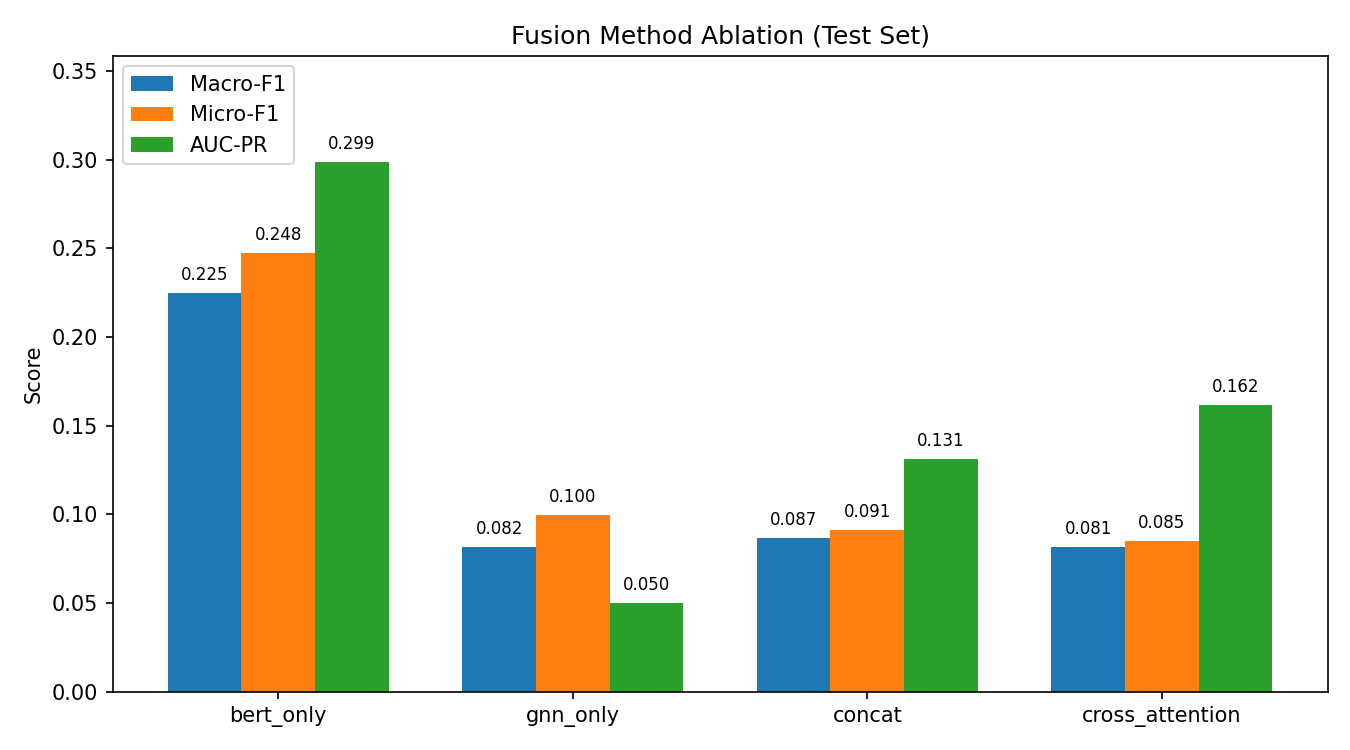


### loss_curves.png  (222.8 KB)


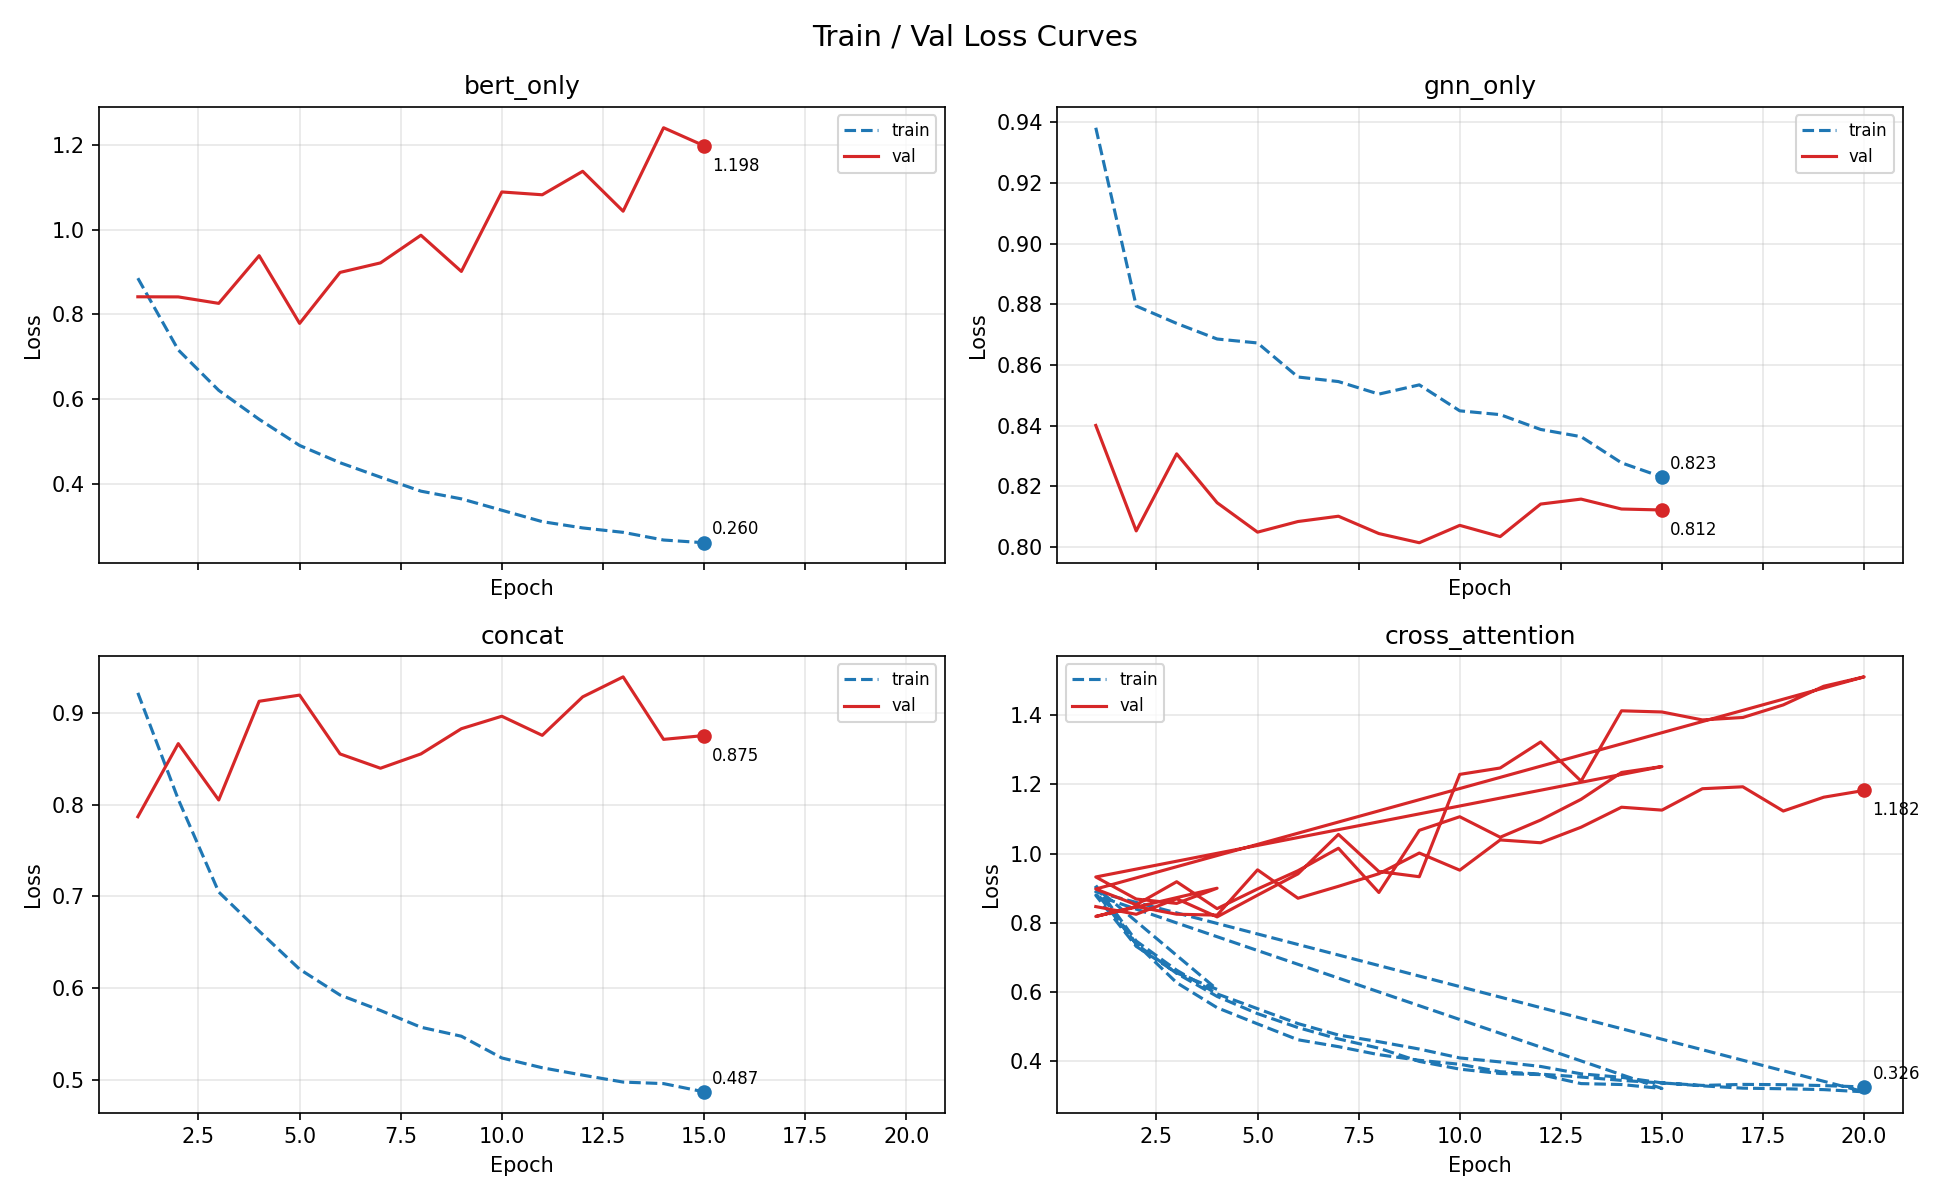


### lr_schedule.png  (40.6 KB)


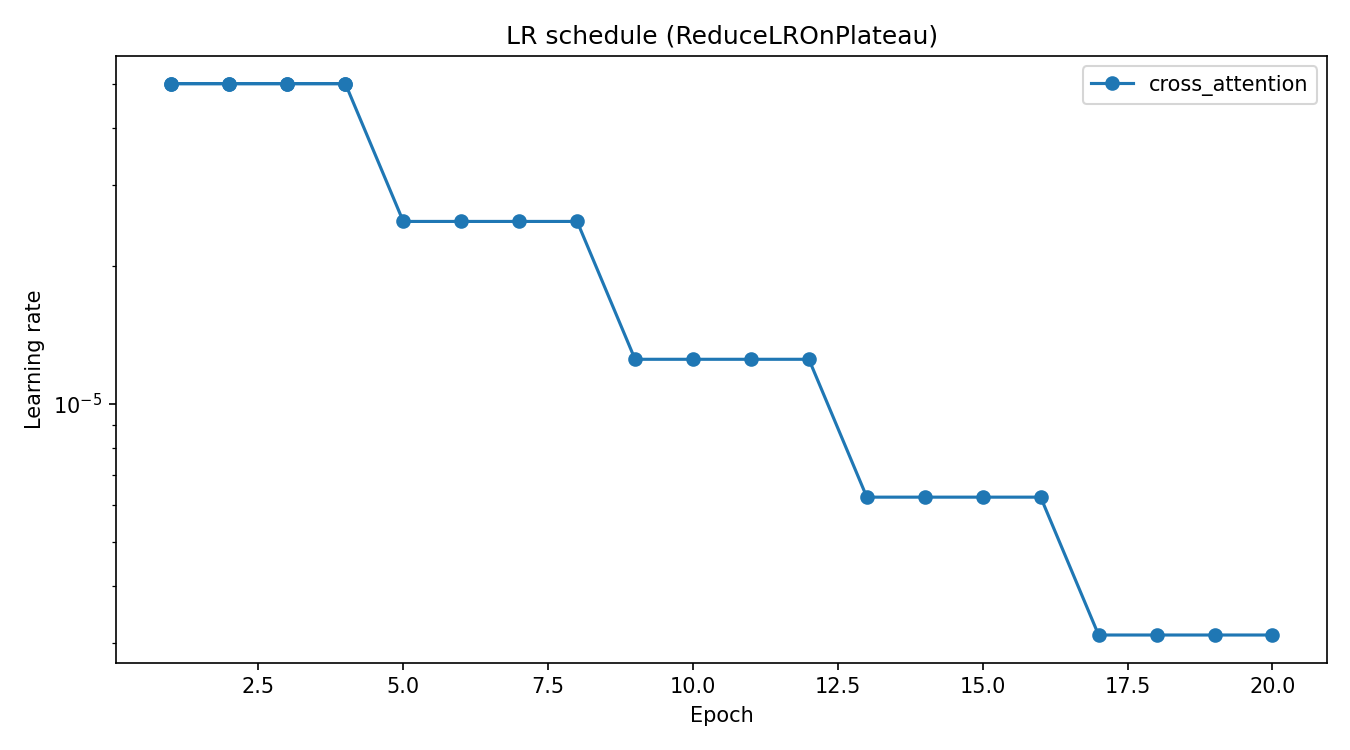

In [ ]:
from pathlib import Path
from IPython.display import Image, display

PLOTS = Path("/content/CSE425_project/results/plots")
for p in sorted(PLOTS.glob("*.png")):
    print(f"\n### {p.name}  ({p.stat().st_size/1024:.1f} KB)")
    display(Image(filename=str(p)))